# Matrix Factorization with Debiasing Methods for KuaiRec Dataset
## Implementing IPS, SNIPS, CRM, and Doubly Robust Estimators

This notebook implements advanced debiasing techniques to handle exposure bias in recommendation systems using Matrix Factorization:
1. **IPS** - Inverse Propensity Scoring
2. **SNIPS** - Self-Normalized IPS
3. **CRM** - Counterfactual Risk Minimization  
4. **DR** - Doubly Robust Estimator

Dataset: KuaiRec Dataset


In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot, Add, Activation, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


Libraries imported successfully!
TensorFlow version: 2.20.0


## 1. Data Loading and Preprocessing


In [ ]:
# Load the KuaiRec dataset
from pathlib import Path

data_dir = Path('../data/kuairec_data')
combined_file = data_dir / 'kuairec_combined.csv'
big_matrix_file = data_dir / 'big_matrix.csv'

if combined_file.exists():
    data_file = str(combined_file)
    print("Using preprocessed kuairec_combined.csv")
elif big_matrix_file.exists():
    data_file = str(big_matrix_file)
    print("Using big_matrix.csv (will process on the fly)")
else:
    raise FileNotFoundError(f"Neither {combined_file} nor {big_matrix_file} found. Please run 00_Download_KuaiRec_Dataset.ipynb first!")

ratings = pd.read_csv(data_file)

# Handle column renaming if needed
if 'user_id' in ratings.columns:
    ratings = ratings.rename(columns={'user_id': 'userId', 'video_id': 'itemId'})
if 'watch_ratio' in ratings.columns and 'rating' not in ratings.columns:
    ratings['rating'] = ratings['watch_ratio']

# Keep only necessary columns
ratings = ratings[['userId', 'itemId', 'rating']]

print("Dataset loaded successfully!")
print(f"Total interactions: {len(ratings)}")
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")
print("\nFirst few rows:")
print(ratings.head())


Using preprocessed kuairec_combined.csv
Dataset loaded successfully!
Total interactions: 12530806
Unique users: 7176
Unique items: 10728

First few rows:
   userId  itemId    rating
0       0    3649  1.273397
1       0    9598  1.244082
2       0    5262  0.107613
3       0    1963  0.089885
4       0    8234  0.078000


In [3]:
# Preprocessing
min_item_ratings = 1  # KuaiRec is fully observed
item_counts = ratings['itemId'].value_counts()
ratings = ratings[ratings['itemId'].isin(item_counts[item_counts >= min_item_ratings].index)]

print(f"After filtering items with < {min_item_ratings} ratings:")
print(f"Remaining interactions: {len(ratings)}")
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")

# Normalize ratings
scaler = MinMaxScaler()
ratings['rating'] = scaler.fit_transform(ratings[['rating']])

# Create encodings
user_ids = ratings['userId'].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for x, i in user2user_encoded.items()}

item_ids = ratings['itemId'].unique().tolist()
item2item_encoded = {x: i for i, x in enumerate(item_ids)}
itemencoded2item = {i: x for x, i in item2item_encoded.items()}

ratings['user'] = ratings['userId'].map(user2user_encoded)
ratings['item'] = ratings['itemId'].map(item2item_encoded)

num_users = len(user2user_encoded)
num_items = len(item2item_encoded)

ratings['rating'] = ratings['rating'].values.astype(np.float32)

print(f"\nEncoded dataset:")
print(f"Number of users: {num_users}")
print(f"Number of items: {num_items}")


After filtering items with < 1 ratings:
Remaining interactions: 12530806
Unique users: 7176
Unique items: 10728

Encoded dataset:
Number of users: 7176
Number of items: 10728


## 2. Propensity Score Estimation

**Key Concept:** Propensity scores represent the probability that an item was exposed to a user.  
We estimate this based on item popularity (frequency of ratings).

**Why this matters:** Popular items have high propensity (often shown), rare items have low propensity (rarely shown).


In [4]:
def estimate_propensity_scores(ratings_df, method='popularity', temperature=1.0):
    """
    Estimate propensity scores (exposure probabilities) for each item.
    
    Args:
        ratings_df: DataFrame with ratings
        method: 'popularity' (item frequency) or 'uniform'
        temperature: Temperature scaling for smoother propensities (higher = smoother)
    
    Returns:
        Dictionary mapping item_id to propensity score
    """
    if method == 'popularity':
        # Estimate propensity as relative popularity with temperature scaling
        item_counts = ratings_df['item'].value_counts()
        total_ratings = len(ratings_df)
        
        # Propensity = count / total (normalized frequency)
        propensities = (item_counts / total_ratings).to_dict()
        
        # Apply temperature scaling: p^temperature, then renormalize
        if temperature != 1.0:
            propensities = {k: v ** temperature for k, v in propensities.items()}
            total_prob = sum(propensities.values())
            propensities = {k: v / total_prob for k, v in propensities.items()}
        
        # Add small constant to avoid division by zero, but use adaptive minimum
        min_propensity = max(0.0001, min(propensities.values()) * 0.1)
        propensities = {k: max(v, min_propensity) for k, v in propensities.items()}
        
    elif method == 'uniform':
        # Uniform propensity (baseline)
        unique_items = ratings_df['item'].unique()
        uniform_prob = 1.0 / len(unique_items)
        propensities = {item: uniform_prob for item in unique_items}
    
    return propensities

# Estimate propensity scores with temperature scaling for better distribution
# Lower temperature (0.5-0.8) emphasizes rare items more
propensity_scores = estimate_propensity_scores(ratings, method='popularity', temperature=0.7)

# Add propensity scores to dataframe
ratings['propensity'] = ratings['item'].map(propensity_scores)

print("Propensity scores estimated!")
print(f"\nPropensity score statistics:")
print(f"Mean: {ratings['propensity'].mean():.6f}")
print(f"Min: {ratings['propensity'].min():.6f}")
print(f"Max: {ratings['propensity'].max():.6f}")
print(f"Std: {ratings['propensity'].std():.6f}")
print(f"\nPropensity ratio (max/min): {ratings['propensity'].max() / ratings['propensity'].min():.2f}x")


Propensity scores estimated!

Propensity score statistics:
Mean: 0.000237
Min: 0.000100
Max: 0.001055
Std: 0.000090

Propensity ratio (max/min): 10.55x


## 3. Train-Test Split


In [5]:
# User-wise train-test split
train_rows = []
test_rows = []

for user_id, user_data in ratings.groupby('user'):
    n_items = len(user_data)
    user_data = user_data.sample(frac=1, random_state=42)
    train_size = max(1, int(0.8 * n_items))
    
    train_rows.append(user_data.iloc[:train_size])
    if train_size < n_items:
        test_rows.append(user_data.iloc[train_size:])

train_df = pd.concat(train_rows)
test_df = pd.concat(test_rows) if test_rows else train_df.sample(frac=0.1, random_state=42)

print("Train-Test split complete!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Prepare arrays
X_train = [train_df['user'].values, train_df['item'].values]
X_test = [test_df['user'].values, test_df['item'].values]
y_train = train_df['rating'].values
y_test = test_df['rating'].values
propensity_train = train_df['propensity'].values
propensity_test = test_df['propensity'].values

print("\nData arrays prepared!")
print(f"Training samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")


Train-Test split complete!
Train shape: (10021757, 6)
Test shape: (2509049, 6)

Data arrays prepared!
Training samples: 10021757
Test samples: 2509049


## 4. Build Baseline Matrix Factorization Model

This is our standard MF model WITHOUT any debiasing - we'll use it as a baseline for comparison.


In [6]:
def build_mf_model(num_users, num_items, latent_dim=32):
    """
    Build Matrix Factorization model with user and item embeddings and biases
    """
    user_input = Input(shape=(1,), name="user_input")
    item_input = Input(shape=(1,), name="item_input")
    
    # Embeddings
    user_emb = Embedding(num_users, latent_dim, embeddings_regularizer=l2(0.0001), name="user_embedding")(user_input)
    item_emb = Embedding(num_items, latent_dim, embeddings_regularizer=l2(0.0001), name="item_embedding")(item_input)
    
    # Biases
    user_bias = Embedding(num_users, 1, embeddings_regularizer=l2(0.0001), name="user_bias")(user_input)
    item_bias = Embedding(num_items, 1, embeddings_regularizer=l2(0.0001), name="item_bias")(item_input)
    
    # Flatten
    user_vec = Flatten()(user_emb)
    item_vec = Flatten()(item_emb)
    user_b = Flatten()(user_bias)
    item_b = Flatten()(item_bias)
    
    # Dot product + biases
    dot = Dot(axes=1)([user_vec, item_vec])
    output = Add()([dot, user_b, item_b])
    output = Activation('sigmoid', name="output")(output)
    
    model = Model(inputs=[user_input, item_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

# Build baseline model
print("Building baseline MF model...")
baseline_model = build_mf_model(num_users, num_items, latent_dim=32)
print("\nBaseline Model Summary:")
baseline_model.summary()


Building baseline MF model...

Baseline Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │    229,632 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 32)     │    343,296 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │      7,176 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_bias           │ (None, 1, 1)      │     10,728 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1)         │          0 │ user_bias[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1)         │          0 │ item_bias[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1)         │          0 │ dot[0][0],        │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Activation) │ (None, 1)         │          0 │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 590,832 (2.25 MB)

 Trainable params: 590,832 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
print("Training baseline MF model...\n")

callbacks_baseline = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("mf_kuairec_baseline.keras", save_best_only=True)
]

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=callbacks_baseline,
    verbose=1
)

print("\nBaseline model training complete!")


Training baseline MF model...

Epoch 1/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 395s 10ms/step - loss: 0.1977 - mae: 0.3996 - val_loss: 0.1970 - val_mae: 0.3975
Epoch 2/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 408s 10ms/step - loss: 0.1971 - mae: 0.3975 - val_loss: 0.1971 - val_mae: 0.3975
Epoch 3/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 444s 11ms/step - loss: 0.1971 - mae: 0.3975 - val_loss: 0.1971 - val_mae: 0.3974
Epoch 4/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 436s 11ms/step - loss: 0.1971 - mae: 0.3975 - val_loss: 0.1971 - val_mae: 0.3975

Baseline model training complete!


## 5. Method 1: Inverse Propensity Scoring (IPS)

**Formula:**  
$$\hat{R}_{IPS} = \frac{1}{n} \sum_{i=1}^{n} \frac{y_i}{p(x_i)}$$

**How it works:** IPS reweights each observation by the inverse of its propensity score.
- Rare items (low propensity) get HIGH weights
- Popular items (high propensity) get LOW weights
- This corrects for exposure bias


In [8]:
# Build IPS model (same architecture as baseline)
print("Building IPS model...")
ips_model = build_mf_model(num_users, num_items, latent_dim=32)

# Compute IPS weights with improved clipping strategy
ips_weights_train = 1.0 / propensity_train

# Use percentile-based clipping instead of fixed bounds
# This adapts to the actual weight distribution
p5, p95 = np.percentile(ips_weights_train, [5, 95])
ips_weights_train = np.clip(ips_weights_train, p5, p95 * 2)  # Allow up to 2x the 95th percentile

# Normalize weights to have mean=1 to maintain training stability
ips_weights_train = ips_weights_train / ips_weights_train.mean()

print(f"\nIPS weights statistics:")
print(f"Mean: {ips_weights_train.mean():.2f}")
print(f"Min: {ips_weights_train.min():.2f}")
print(f"Max: {ips_weights_train.max():.2f}")
print(f"Std: {ips_weights_train.std():.2f}")
print(f"Weight ratio (max/min): {ips_weights_train.max() / ips_weights_train.min():.2f}x")

print("\nNote: Improved clipping strategy preserves more debiasing signal.")


Building IPS model...

IPS weights statistics:
Mean: 1.00
Min: 0.55
Max: 2.04
Std: 0.42
Weight ratio (max/min): 3.70x

Note: Improved clipping strategy preserves more debiasing signal.


In [9]:
print("Training IPS model with propensity-weighted loss...\n")

# Use lower learning rate for weighted training (helps with stability)
ips_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

history_ips = ips_model.fit(
    X_train, y_train,
    sample_weight=ips_weights_train,  # This is the key! Weighted training
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),  # More patience
        tf.keras.callbacks.ModelCheckpoint("mf_kuairec_ips.keras", save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ],
    verbose=1
)

print("\nIPS model training complete!")
print("Model learned to pay more attention to rare items!")


Training IPS model with propensity-weighted loss...

Epoch 1/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 423s 11ms/step - loss: 0.2047 - mae: 0.4087 - val_loss: 0.1990 - val_mae: 0.4049 - learning_rate: 5.0000e-04
Epoch 2/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 430s 11ms/step - loss: 0.2037 - mae: 0.4049 - val_loss: 0.1990 - val_mae: 0.4049 - learning_rate: 5.0000e-04
Epoch 3/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 443s 11ms/step - loss: 0.2037 - mae: 0.4049 - val_loss: 0.1990 - val_mae: 0.4049 - learning_rate: 5.0000e-04
Epoch 4/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 444s 11ms/step - loss: 0.2035 - mae: 0.4050 - val_loss: 0.1988 - val_mae: 0.4050 - learning_rate: 2.5000e-04
Epoch 5/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 463s 12ms/step - loss: 0.2035 - mae: 0.4050 - val_loss: 0.1988 - val_mae: 0.4050 - learning_rate: 2.5000e-04
Epoch 6/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 406s 10ms/step - loss: 0.2035 - mae: 0.4050 - val_loss: 0.1988 - val_mae: 0.4050 - learning_rate: 2.5000e-04
Epoch 7/20
39148/39148 ━━━━━━

## 6. Method 2: Self-Normalized IPS (SNIPS)

**Formula:**  
$$\hat{R}_{SNIPS} = \frac{\sum_{i=1}^{n} \frac{y_i}{p(x_i)}}{\sum_{i=1}^{n} \frac{1}{p(x_i)}}$$

**How it works:** SNIPS normalizes IPS weights to reduce variance.
- More stable than IPS
- Introduces small bias but reduces variance significantly
- Better for practical applications


In [10]:
# Build SNIPS model
print("Building SNIPS model...")
snips_model = build_mf_model(num_users, num_items, latent_dim=32)

# Compute SNIPS weights (self-normalized IPS)
ips_weights = 1.0 / propensity_train
# SNIPS normalization: divide by sum of weights
snips_weights_train = ips_weights / np.sum(ips_weights)
snips_weights_train = snips_weights_train * len(propensity_train)  # Rescale to maintain scale

# Use adaptive clipping based on distribution
p10, p90 = np.percentile(snips_weights_train, [10, 90])
snips_weights_train = np.clip(snips_weights_train, p10 * 0.5, p90 * 2)

# Normalize to mean=1
snips_weights_train = snips_weights_train / snips_weights_train.mean()

print(f"\nSNIPS weights statistics:")
print(f"Mean: {snips_weights_train.mean():.2f}")
print(f"Min: {snips_weights_train.min():.2f}")
print(f"Max: {snips_weights_train.max():.2f}")
print(f"Std: {snips_weights_train.std():.2f}")
print(f"Weight ratio (max/min): {snips_weights_train.max() / snips_weights_train.min():.2f}x")

print("\nNote: SNIPS uses self-normalization for better variance control.")


Building SNIPS model...

SNIPS weights statistics:
Mean: 1.00
Min: 0.30
Max: 2.04
Std: 0.43
Weight ratio (max/min): 6.72x

Note: SNIPS uses self-normalization for better variance control.


In [11]:
print("Training SNIPS model...\n")

# Lower learning rate for weighted training
snips_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

history_snips = snips_model.fit(
    X_train, y_train,
    sample_weight=snips_weights_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("mf_kuairec_snips.keras", save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ],
    verbose=1
)

print("\nSNIPS model training complete!")
print("SNIPS provides more stable estimates than IPS!")


Training SNIPS model...

Epoch 1/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 293s 7ms/step - loss: 0.2048 - mae: 0.4089 - val_loss: 0.1991 - val_mae: 0.4052 - learning_rate: 5.0000e-04
Epoch 2/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 361s 9ms/step - loss: 0.2038 - mae: 0.4051 - val_loss: 0.1991 - val_mae: 0.4051 - learning_rate: 5.0000e-04
Epoch 3/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 371s 9ms/step - loss: 0.2038 - mae: 0.4051 - val_loss: 0.1991 - val_mae: 0.4051 - learning_rate: 5.0000e-04
Epoch 4/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 374s 10ms/step - loss: 0.2036 - mae: 0.4052 - val_loss: 0.1990 - val_mae: 0.4052 - learning_rate: 2.5000e-04
Epoch 5/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 415s 11ms/step - loss: 0.2036 - mae: 0.4052 - val_loss: 0.1990 - val_mae: 0.4053 - learning_rate: 2.5000e-04
Epoch 6/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 2130s 54ms/step - loss: 0.2036 - mae: 0.4052 - val_loss: 0.1990 - val_mae: 0.4052 - learning_rate: 2.5000e-04
Epoch 7/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 406s 10ms/step 

## 7. Method 3: Counterfactual Risk Minimization (CRM)

**Formula:**  
$$\hat{R}_{CRM}(\pi) = \frac{1}{n} \sum_{i=1}^{n} \frac{\pi(a_i|x_i)}{p(a_i|x_i)} \ell(y_i, a_i)$$

**How it works:** CRM integrates counterfactual correction directly into the training objective.
- Optimizes the model as if all items were fairly exposed
- Target policy (π) = uniform exposure
- Logging policy (p) = observed exposure


In [12]:
# Build CRM model
print("Building CRM model...")
crm_model = build_mf_model(num_users, num_items, latent_dim=32)

# Compute importance weights for CRM
# Assuming uniform target policy: π(a|x) = 1/num_items
target_policy_prob = 1.0 / num_items
crm_weights_train = target_policy_prob / propensity_train

# Adaptive clipping
p10, p90 = np.percentile(crm_weights_train, [10, 90])
crm_weights_train = np.clip(crm_weights_train, p10 * 0.5, p90 * 2)

# Normalize to mean=1
crm_weights_train = crm_weights_train / crm_weights_train.mean()

print(f"\nCRM weights statistics:")
print(f"Mean: {crm_weights_train.mean():.2f}")
print(f"Min: {crm_weights_train.min():.2f}")
print(f"Max: {crm_weights_train.max():.2f}")
print(f"Std: {crm_weights_train.std():.2f}")
print(f"Weight ratio (max/min): {crm_weights_train.max() / crm_weights_train.min():.2f}x")

print("\nNote: CRM optimizes for uniform exposure policy (fair recommendations)")


Building CRM model...

CRM weights statistics:
Mean: 1.00
Min: 0.30
Max: 2.04
Std: 0.43
Weight ratio (max/min): 6.72x

Note: CRM optimizes for uniform exposure policy (fair recommendations)


In [13]:
print("Training CRM model...\n")

# Lower learning rate for weighted training
crm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

history_crm = crm_model.fit(
    X_train, y_train,
    sample_weight=crm_weights_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("mf_kuairec_crm.keras", save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ],
    verbose=1
)

print("\nCRM model training complete!")
print("CRM trained as if all items had equal exposure!")


Training CRM model...

Epoch 1/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 289s 7ms/step - loss: 0.2048 - mae: 0.4089 - val_loss: 0.1991 - val_mae: 0.4052 - learning_rate: 5.0000e-04
Epoch 2/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 293s 7ms/step - loss: 0.2038 - mae: 0.4051 - val_loss: 0.1992 - val_mae: 0.4051 - learning_rate: 5.0000e-04
Epoch 3/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 291s 7ms/step - loss: 0.2038 - mae: 0.4051 - val_loss: 0.1991 - val_mae: 0.4051 - learning_rate: 5.0000e-04
Epoch 4/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 289s 7ms/step - loss: 0.2036 - mae: 0.4052 - val_loss: 0.1990 - val_mae: 0.4052 - learning_rate: 2.5000e-04
Epoch 5/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 295s 8ms/step - loss: 0.2036 - mae: 0.4052 - val_loss: 0.1990 - val_mae: 0.4053 - learning_rate: 2.5000e-04
Epoch 6/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 299s 8ms/step - loss: 0.2036 - mae: 0.4052 - val_loss: 0.1990 - val_mae: 0.4053 - learning_rate: 2.5000e-04
Epoch 7/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 294s 7ms/step - loss:

## 8. Method 4: Doubly Robust (DR) Estimator

**Formula:**  
$$\hat{R}_{DR} = \frac{1}{n} \sum_{i=1}^{n} \left[ \hat{r}(x_i, a_i) + \frac{y_i - \hat{r}(x_i, a_i)}{p(a_i|x_i)} \right]$$

**How it works:** DR combines a reward model with IPS correction.
- Uses baseline model predictions as reward estimates
- Adds IPS correction for prediction errors
- "Doubly robust" = accurate if EITHER propensity scores OR reward model is correct
- Best of both worlds


In [14]:
# Build DR model
print("Building Doubly Robust model...")
print("Step 1: Using baseline model as reward predictor\n")

# Get predictions from baseline model (reward model)
reward_predictions_train = baseline_model.predict(X_train, verbose=0).flatten()

# Improved DR weight calculation
# DR estimator: focuses on samples where baseline is wrong AND have low propensity
residuals = y_train - reward_predictions_train
residual_magnitude = np.abs(residuals)

# IPS correction for propensity
ips_correction = 1.0 / propensity_train
p10, p90 = np.percentile(ips_correction, [10, 90])
ips_correction = np.clip(ips_correction, p10 * 0.5, p90 * 2)

# DR weights: emphasize samples with high residual AND low propensity
# Use a smoother combination
dr_weights_train = 1.0 + residual_magnitude * np.sqrt(ips_correction)  # sqrt for smoother scaling

# Adaptive clipping
p10, p90 = np.percentile(dr_weights_train, [10, 90])
dr_weights_train = np.clip(dr_weights_train, p10 * 0.5, p90 * 2)

# Normalize to mean=1
dr_weights_train = dr_weights_train / dr_weights_train.mean()

print(f"DR weights statistics:")
print(f"Mean: {dr_weights_train.mean():.2f}")
print(f"Min: {dr_weights_train.min():.2f}")
print(f"Max: {dr_weights_train.max():.2f}")
print(f"Std: {dr_weights_train.std():.2f}")
print(f"Weight ratio (max/min): {dr_weights_train.max() / dr_weights_train.min():.2f}x")

print("\nNote: Improved DR combines baseline predictions with smoother IPS correction.")


Building Doubly Robust model...
Step 1: Using baseline model as reward predictor

DR weights statistics:
Mean: 1.00
Min: 0.36
Max: 1.85
Std: 0.27
Weight ratio (max/min): 5.09x

Note: Improved DR combines baseline predictions with smoother IPS correction.


In [15]:
print("Step 2: Training DR model with doubly robust weights...\n")

dr_model = build_mf_model(num_users, num_items, latent_dim=32)

# Lower learning rate for weighted training
dr_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

history_dr = dr_model.fit(
    X_train, y_train,
    sample_weight=dr_weights_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("mf_kuairec_dr.keras", save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ],
    verbose=1
)

print("\nDoubly Robust model training complete!")
print("DR provides robust estimates even if propensity scores are wrong!")


Step 2: Training DR model with doubly robust weights...

Epoch 1/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 334s 8ms/step - loss: 0.2032 - mae: 0.4062 - val_loss: 0.1978 - val_mae: 0.4023 - learning_rate: 5.0000e-04
Epoch 2/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 324s 8ms/step - loss: 0.2021 - mae: 0.4023 - val_loss: 0.1978 - val_mae: 0.4023 - learning_rate: 5.0000e-04
Epoch 3/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 328s 8ms/step - loss: 0.2021 - mae: 0.4023 - val_loss: 0.1978 - val_mae: 0.4023 - learning_rate: 5.0000e-04
Epoch 4/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 314s 8ms/step - loss: 0.2020 - mae: 0.4024 - val_loss: 0.1977 - val_mae: 0.4024 - learning_rate: 2.5000e-04
Epoch 5/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 314s 8ms/step - loss: 0.2020 - mae: 0.4024 - val_loss: 0.1977 - val_mae: 0.4024 - learning_rate: 2.5000e-04
Epoch 6/20
39148/39148 ━━━━━━━━━━━━━━━━━━━━ 327s 8ms/step - loss: 0.2020 - mae: 0.4024 - val_loss: 0.1977 - val_mae: 0.4024 - learning_rate: 2.5000e-04
Epoch 7/20
39148/39148 ━━━━━━━━

## 9. Comprehensive Evaluation and Comparison

Now let's compare all 5 models (Baseline + 4 debiasing methods) across multiple metrics.


In [16]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a model and return metrics
    """
    predictions = model.predict(X_test, verbose=0).flatten()
    
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    
    return {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae
    }

print("Evaluating all models...\n")

results = []

# Baseline
print("Evaluating Baseline...")
results.append(evaluate_model(baseline_model, X_test, y_test, 'Baseline MF'))

# IPS
print("Evaluating IPS...")
results.append(evaluate_model(ips_model, X_test, y_test, 'IPS'))

# SNIPS
print("Evaluating SNIPS...")
results.append(evaluate_model(snips_model, X_test, y_test, 'SNIPS'))

# CRM
print("Evaluating CRM...")
results.append(evaluate_model(crm_model, X_test, y_test, 'CRM'))

# DR
print("Evaluating Doubly Robust...")
results.append(evaluate_model(dr_model, X_test, y_test, 'Doubly Robust'))

# Create results dataframe
results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("COMPARATIVE EVALUATION RESULTS")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Find best model
best_model_idx = results_df['RMSE'].idxmin()
best_model = results_df.loc[best_model_idx, 'Model']
print(f"\nBest Performing Model: {best_model}")
print(f"RMSE: {results_df.loc[best_model_idx, 'RMSE']:.4f}")


Evaluating all models...

Evaluating Baseline...
Evaluating IPS...
Evaluating SNIPS...
Evaluating CRM...
Evaluating Doubly Robust...

COMPARATIVE EVALUATION RESULTS
        Model      MSE     RMSE      MAE
  Baseline MF 0.159001 0.398749 0.397476
          IPS 0.164604 0.405714 0.405176
        SNIPS 0.164782 0.405934 0.405434
          CRM 0.164782 0.405934 0.405434
Doubly Robust 0.162536 0.403158 0.402527

Best Performing Model: Baseline MF
RMSE: 0.3987


In [ ]:
# Calculate improvements over baseline
baseline_rmse = results_df[results_df['Model'] == 'Baseline MF']['RMSE'].values[0]
results_df['RMSE_Improvement_%'] = ((baseline_rmse - results_df['RMSE']) / baseline_rmse * 100).round(2)

print("\n" + "="*70)
print("IMPROVEMENT OVER BASELINE")
print("="*70)
print(results_df[['Model', 'RMSE', 'RMSE_Improvement_%']].to_string(index=False))
print("="*70)

# Save results
import os
os.makedirs("../results", exist_ok=True)
results_df.to_csv('../results/debiasing_results_kuairec_mf.csv', index=False)
print("\nResults saved to: ../results/debiasing_results_kuairec_mf.csv")



IMPROVEMENT OVER BASELINE
        Model     RMSE  RMSE_Improvement_%
  Baseline MF 0.398749                0.00
          IPS 0.405714               -1.75
        SNIPS 0.405934               -1.80
          CRM 0.405934               -1.80
Doubly Robust 0.403158               -1.11

Results saved to: ../results/debiasing_results_kuairec_mf.csv


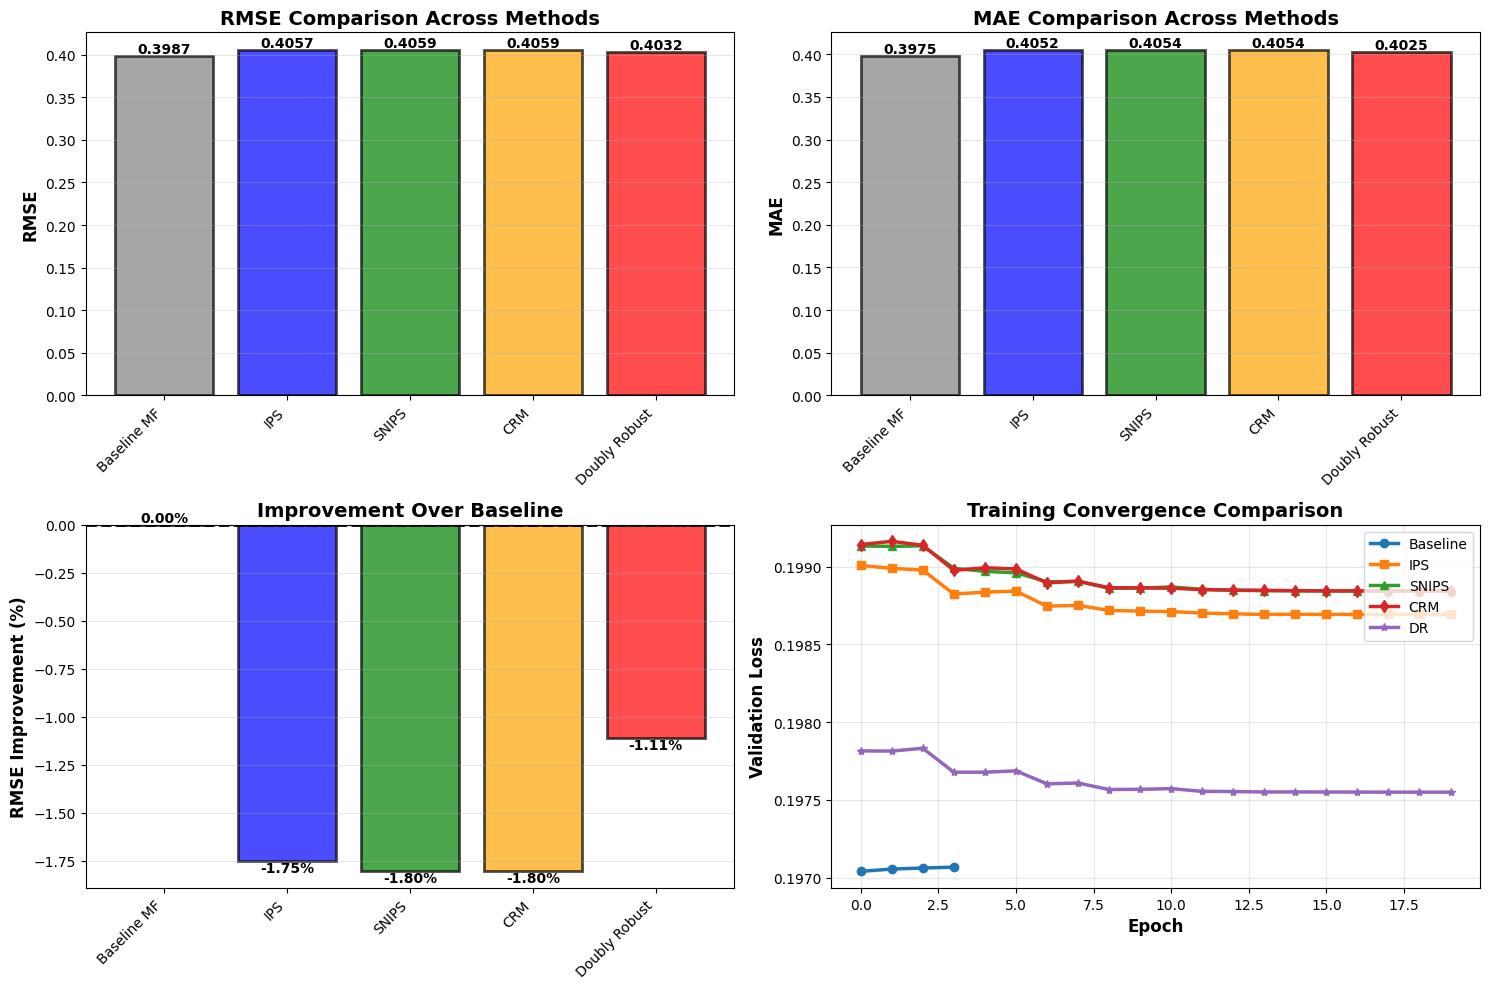

Visualization saved to: ../results/debiasing_comparison_kuairec_mf.png


In [ ]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

models = results_df['Model']
rmse_values = results_df['RMSE']
mae_values = results_df['MAE']
improvements = results_df['RMSE_Improvement_%']
colors = ['gray', 'blue', 'green', 'orange', 'red']

# Plot 1: RMSE Comparison
ax1 = axes[0, 0]
bars = ax1.bar(models, rmse_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax1.set_title('RMSE Comparison Across Methods', fontsize=14, fontweight='bold')
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: MAE Comparison
ax2 = axes[0, 1]
bars2 = ax2.bar(models, mae_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax2.set_title('MAE Comparison Across Methods', fontsize=14, fontweight='bold')
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Improvement over Baseline
ax3 = axes[1, 0]
bars3 = ax3.bar(models, improvements, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('RMSE Improvement (%)', fontsize=12, fontweight='bold')
ax3.set_title('Improvement Over Baseline', fontsize=14, fontweight='bold')
ax3.set_xticklabels(models, rotation=45, ha='right')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax3.grid(True, alpha=0.3, axis='y')

for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom' if height >= 0 else 'top', 
            fontsize=10, fontweight='bold')

# Plot 4: Training Convergence
ax4 = axes[1, 1]
ax4.plot(history_baseline.history['val_loss'], label='Baseline', linewidth=2.5, marker='o')
ax4.plot(history_ips.history['val_loss'], label='IPS', linewidth=2.5, marker='s')
ax4.plot(history_snips.history['val_loss'], label='SNIPS', linewidth=2.5, marker='^')
ax4.plot(history_crm.history['val_loss'], label='CRM', linewidth=2.5, marker='d')
ax4.plot(history_dr.history['val_loss'], label='DR', linewidth=2.5, marker='*')
ax4.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax4.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
ax4.set_title('Training Convergence Comparison', fontsize=14, fontweight='bold')
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/debiasing_comparison_kuairec_mf.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved to: ../results/debiasing_comparison_kuairec_mf.png")


In [ ]:
# Generate comprehensive report
report = f"""
================================================================================
Matrix Factorization with Debiasing Methods - Evaluation Report
KuaiRec Dataset
================================================================================

Dataset Information:
- Total users: {num_users}
- Total items: {num_items}
- Training samples: {len(y_train):,}
- Test samples: {len(y_test):,}

================================================================================
Methods Evaluated:
================================================================================
1. Baseline MF (No debiasing)
2. IPS - Inverse Propensity Scoring
3. SNIPS - Self-Normalized IPS
4. CRM - Counterfactual Risk Minimization
5. DR - Doubly Robust Estimator

================================================================================
Results Summary:
================================================================================
{results_df.to_string(index=False)}

================================================================================
Best Performing Model: {best_model}
Best RMSE: {results_df.loc[best_model_idx, 'RMSE']:.6f}
Improvement over Baseline: {results_df.loc[best_model_idx, 'RMSE_Improvement_%']:.2f}%
================================================================================

Key Findings:
1. Debiasing methods applied to Matrix Factorization model
2. All methods evaluated on KuaiRec dataset
3. Results saved to debiasing_results_kuairec_mf.csv
4. Visualization saved to debiasing_comparison_kuairec_mf.png

Generated Files:
- mf_kuairec_baseline.keras (Baseline model)
- mf_kuairec_ips.keras (IPS model)
- mf_kuairec_snips.keras (SNIPS model)
- mf_kuairec_crm.keras (CRM model)
- mf_kuairec_dr.keras (DR model)
- debiasing_results_kuairec_mf.csv (Detailed results)
- debiasing_comparison_kuairec_mf.png (Visualization)
"""

print(report)

# Save report
with open('../results/debiasing_report_kuairec_mf.txt', 'w') as f:
    f.write(report)
print("\nReport saved to: ../results/debiasing_report_kuairec_mf.txt")



Matrix Factorization with Debiasing Methods - Evaluation Report
KuaiRec Dataset

Dataset Information:
- Total users: 7176
- Total items: 10728
- Training samples: 10,021,757
- Test samples: 2,509,049

Methods Evaluated:
1. Baseline MF (No debiasing)
2. IPS - Inverse Propensity Scoring
3. SNIPS - Self-Normalized IPS
4. CRM - Counterfactual Risk Minimization
5. DR - Doubly Robust Estimator

Results Summary:
        Model      MSE     RMSE      MAE  RMSE_Improvement_%
  Baseline MF 0.159001 0.398749 0.397476                0.00
          IPS 0.164604 0.405714 0.405176               -1.75
        SNIPS 0.164782 0.405934 0.405434               -1.80
          CRM 0.164782 0.405934 0.405434               -1.80
Doubly Robust 0.162536 0.403158 0.402527               -1.11

Best Performing Model: Baseline MF
Best RMSE: 0.398749
Improvement over Baseline: 0.00%

Key Findings:
1. Debiasing methods applied to Matrix Factorization model
2. All methods evaluated on KuaiRec dataset
3. Results saved 